## pipeline step 6: post-processing

tasks:
* create distribution plots (to be stored as .png files)
* perform t-tests
* create latex-layout tables for av+st.dev and t-tests

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy
from scipy.stats import f_oneway, ttest_rel
from pathlib import Path
import os
from PIL import Image

* collect all csv-files
* remove the time stamps
* read contents in a pandas dataframe
note: for each directory, only the newest dataframe is taken (due to the sort())

In [90]:
root_dir = '.'
csv_list = list(Path(root_dir).glob("_data*.csv"))
csv_list.sort()
#print(csv_list)
df_list_all = {}
for csv in csv_list:
    # remove time stamp
    csv_stem = '_'.join(csv.stem.split('_')[:-2])
    df_list_all[csv_stem] = pd.read_csv(csv)

df_list_all['_123_edge800'] = df_list_all['_data_edge1'].copy()
df_list_all['_123_edge4000'] = df_list_all['_data_edge5'].copy()
df_list_all['_123_unet800'] = df_list_all['_data_all_tests_test1_epoch3'].copy()
df_list_all['_123_unet2400'] = df_list_all['_data_all_tests_test3_epoch3'].copy()
df_list_all['_123_unet4000'] = df_list_all['_data_all_tests_test5_epoch3'].copy()
print()
print(df_list_all.keys())


dict_keys(['_data_all_tests_test1_epoch1', '_data_all_tests_test1_epoch2', '_data_all_tests_test1_epoch3', '_data_all_tests_test1_epoch5', '_data_all_tests_test1_epoch6', '_data_all_tests_test1_epoch8', '_data_all_tests_test3_epoch1', '_data_all_tests_test3_epoch2', '_data_all_tests_test3_epoch3', '_data_all_tests_test5_epoch1', '_data_all_tests_test5_epoch2', '_data_all_tests_test5_epoch3', '_data_DATA_FINAL_test_input', '_data_DATA_FINAL_test_target', '_data_e_d_g_e', '_data_edge1', '_data_edge5', '_123_edge800', '_123_edge4000', '_123_unet800', '_123_unet2400', '_123_unet4000'])


* merge the separate OCR-df's into one, and rename each normalize-match column to reflect the origin

In [64]:
def merge_df(_df_keys):
    _df_keys = ['_data_DATA_FINAL_test_input'] + _df_keys
    _df_list = [ df_list_all[f][['source','match_norm']].rename(columns={'match_norm':f.split('_')[-1]}) for f in _df_keys]
    _df_merged = _df_list[0]
    for _df in _df_list[1:]:
        _df_merged = pd.merge(_df_merged, _df, on="source")
        # make sure that inner-join equals outer-join
        if len(_df)!=len(_df_merged):
            print('ERROR: incomplete merge', _df.columns)    
    #print(_df_merged.columns)
    for c in _df_merged.columns[2:]:
        _df_merged['pair-input-' + c] = _df_merged[c] - _df_merged.input
    print(_df_merged.columns)
    return _df_merged

* create various merged dataframes, each for a different investigation

In [65]:
_df_keys =  ['_data_all_tests_test1_epoch8', '_data_all_tests_test5_epoch3']
df_18_35 = merge_df(_df_keys)

Index(['source', 'input', 'epoch8', 'epoch3', 'pair-input-epoch8',
       'pair-input-epoch3'],
      dtype='object')


In [66]:
target = '123'
_df_keys =  list(filter(lambda x: target in x, df_list_all.keys()))
df_all_merged = merge_df(_df_keys)

Index(['source', 'input', 'edge800', 'edge4000', 'unet800', 'unet2400',
       'unet4000', 'pair-input-edge800', 'pair-input-edge4000',
       'pair-input-unet800', 'pair-input-unet2400', 'pair-input-unet4000'],
      dtype='object')


In [87]:
target = 'target'
_df_keys = list(filter(lambda x: target in x, df_list_all.keys())) 
df_identity_merged = merge_df(_df_keys)

Index(['source', 'input', 'target', 'pair-input-target'], dtype='object')


In [68]:
target = 'test1'
_df_keys = list(filter(lambda x: target in x, df_list_all.keys()))
df_test1_merged = merge_df(_df_keys)

Index(['source', 'input', 'epoch1', 'epoch2', 'epoch3', 'epoch5', 'epoch6',
       'epoch8', 'pair-input-epoch1', 'pair-input-epoch2', 'pair-input-epoch3',
       'pair-input-epoch5', 'pair-input-epoch6', 'pair-input-epoch8'],
      dtype='object')


* helper functions for the plots with saving plots to file (for easy importing in Overleaf)
* two-sided t-test (incl. latex table)

In [74]:
# get min and max of the series (to set the x-axis)
def min_max(x, xlim):
    mu0 = x.mean()
    sd0 = x.std(ddof=1)
    xlim[0] = min(xlim[0], min(x),mu0-1*sd0)
    xlim[1] = max(xlim[1], max(x),mu0+1*sd0)

# determine the number of bins (preferably equal to the number of different x-values)
def bin(df, columns):
    values = set()
    xlim=[0,0]
    for column in columns:
        values |= set(df[column].unique())
        min_max(df[column], xlim)
    #print(values)
    nrof_bins = len(values)+1
    if nrof_bins>13:
        nrof_bins=13
    bins = np.linspace(min(values), max(values), nrof_bins)
    return bins, xlim

# create a stylized normal curve representing the distribution
def stylized(x, color, label, bins, xlim, factor):
    #plt.hist(x, bins, alpha=0.5, label=label)
    mu0 = x.mean()
    sd0 = x.std(ddof=1)
    print(f"\\textit{{{label}}} & {mu0:.2f} & {sd0:.2f} \\\\")
    x = np.linspace(*xlim,100)
    factor = len(x)/len(bins) * factor
    y0 = scipy.stats.norm.pdf(x,mu0,sd0) * factor
    plt.plot(x,y0,color,linestyle='dashed',linewidth=0.8, label=label)

# create the plot (with several configuration options)
def histo(df, columns, factor, with_stylized=True, with_histo=True, filename='histo', xlabel_prefix=''):
    plt.rc('figure', figsize=(6, 3))
    if with_histo:
        bins,xlim = bin(df, columns)
        plt.hist([df[column] for column in columns], bins, alpha=0.5, label=[column for column in columns])
    else:
        bins, xlim = [1], [-0.09, 1.09]
        factor = 1.0 / len(df)
    if with_stylized:
        for column,color in zip(columns,mcolors.TABLEAU_COLORS):
            if with_histo:
                stylized_labels=None
            else:
                stylized_labels=column
            stylized(df[column], color, label=stylized_labels, bins=bins, xlim=xlim, factor=factor)

    plt.xlim(xlim)
    plt.legend() #loc='upper left')
    plt.xlabel(xlabel_prefix + 'match coefficient')
    plt.grid(visible=True)
    ax = plt.gca()
    ax.spines['left'].set_visible(True)   # Show left spine (y-axis line)
    ax.spines['bottom'].set_visible(True) # Show bottom spine (x-axis line)
    
    # Hide the y-axis tick labels
    if with_histo is False:
        ax.set_yticklabels([])  # Hide y-axis values
    
    # Optionally, hide the y-axis ticks (the small lines)
    ax.yaxis.set_ticks_position('none')
    
    plt.savefig(filename + '.png', bbox_inches='tight')
    plt.show()

def ttest(df, left, right, with_debug=False):
    reference=0
    diff = 'pair-' + left + '-' + right
    t_statistic, p_value = scipy.stats.ttest_1samp(df[diff], popmean=reference)
    if with_debug: 
        print(t_statistic, p_value)
    
    print(f"\\textit{{{right}}} & {t_statistic:.2f} & {p_value:.2f} \\\\")

    t_statistic, p_value = scipy.stats.ttest_rel(df[left], df[right])
    if with_debug: 
        print(t_statistic, p_value)

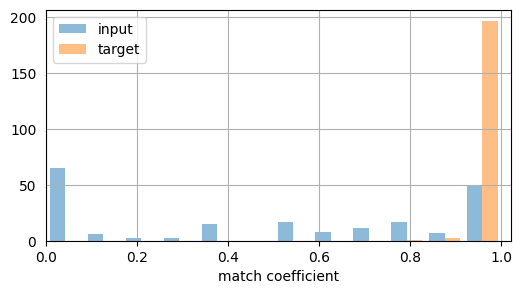

failing targets:
            source     input    target  pair-input-target
104    mice_007470  0.000000  0.750000           0.750000
106  monroe_007576  0.166667  0.833333           0.666667
107  monroe_007577  0.333333  0.833333           0.500000


In [88]:
columns = df_identity_merged.columns[1:len(df_identity_merged.columns)//2+1] 

histo(df_identity_merged, columns, with_stylized=False, with_histo=True, factor=5, filename='histo_target')
print('failing targets:')
print(df_identity_merged[df_identity_merged.target<1])

\textit{input} & 0.48 & 0.40 \\
\textit{epoch1} & 0.76 & 0.28 \\
\textit{epoch2} & 0.88 & 0.20 \\
\textit{epoch3} & 0.89 & 0.21 \\
\textit{epoch5} & 0.91 & 0.15 \\
\textit{epoch6} & 0.94 & 0.13 \\
\textit{epoch8} & 0.96 & 0.11 \\


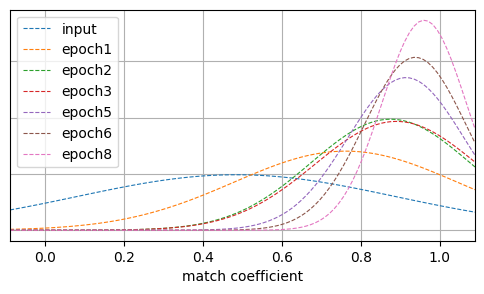

In [91]:
columns = df_test1_merged.columns[1:len(df_test1_merged.columns)//2+1]

histo(df_test1_merged, columns, with_histo=False, factor=4, filename='histo_test1')

\textit{input} & 0.48 & 0.40 \\
\textit{edge800} & 0.12 & 0.22 \\
\textit{edge4000} & 0.10 & 0.24 \\
\textit{unet800} & 0.89 & 0.21 \\
\textit{unet2400} & 0.93 & 0.15 \\
\textit{unet4000} & 0.98 & 0.08 \\


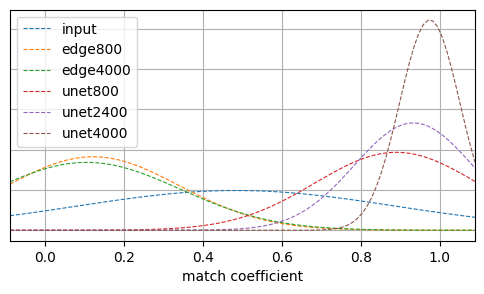

In [92]:
columns = df_all_merged.columns[1:len(df_all_merged.columns)//2+1]

histo(df_all_merged, columns, with_histo=False, factor=4, filename='histo_all_epoch3')

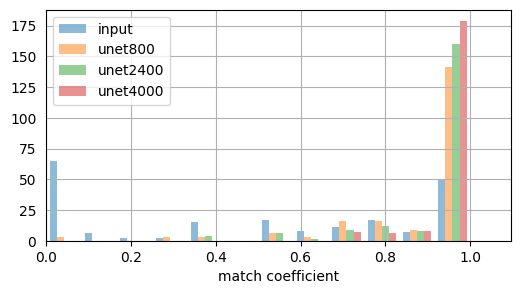

In [78]:
columns = [ 'input', 'unet800', 'unet2400',  'unet4000', ]

histo(df_all_merged, columns, factor=3, with_stylized=False, filename='histo_epoch3')

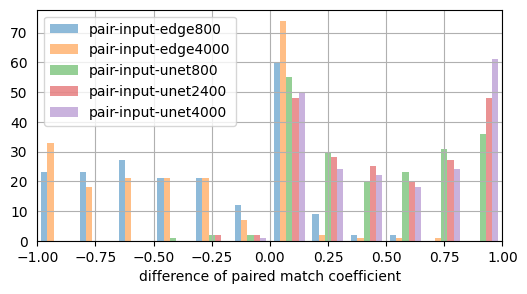

\textit{edge800} & -13.24 & 0.00 \\
\textit{edge4000} & -13.40 & 0.00 \\
\textit{unet800} & 15.39 & 0.00 \\
\textit{unet2400} & 16.67 & 0.00 \\
\textit{unet4000} & 17.68 & 0.00 \\


In [79]:
columns = df_all_merged.columns[len(df_all_merged.columns)//2+1:]

histo(df_all_merged, columns, factor=4, with_stylized=False, filename='histo_all_ttest', xlabel_prefix='difference of paired ')
ttest(df_all_merged, 'input','edge800')
ttest(df_all_merged, 'input','edge4000')
ttest(df_all_merged, 'input','unet800')
ttest(df_all_merged, 'input','unet2400')
ttest(df_all_merged, 'input','unet4000')

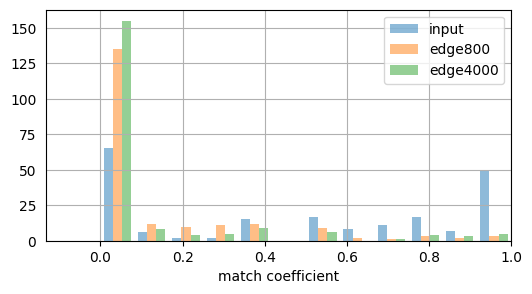

In [81]:
columns = [ 'input',  'edge800',  'edge4000', ]

histo(df_all_merged, columns, factor=4, with_stylized=False, filename='histo_edge')

\textit{None} & 0.41 & 0.37 \\
\textit{None} & 0.45 & 0.38 \\
\textit{None} & 0.49 & 0.39 \\


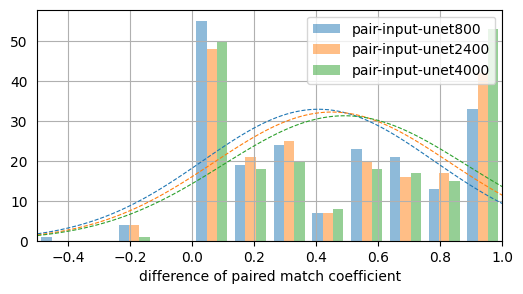

\textit{unet800} & 15.39 & 0.00 \\
\textit{unet2400} & 16.67 & 0.00 \\
\textit{unet4000} & 17.68 & 0.00 \\


In [82]:
columns = [ 'pair-input-unet800',  'pair-input-unet2400',  'pair-input-unet4000', ]
histo(df_all_merged, columns, factor=4, with_stylized=True, filename='histo_unet_ttest', xlabel_prefix='difference of paired ')
ttest(df_all_merged, 'input','unet800')
ttest(df_all_merged, 'input','unet2400')
ttest(df_all_merged, 'input','unet4000')

\textit{None} & -0.36 & 0.39 \\
\textit{None} & -0.38 & 0.40 \\


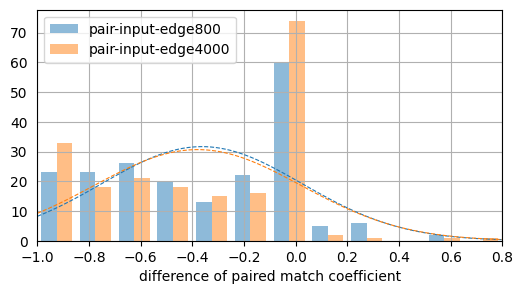

\textit{edge800} & -13.24 & 0.00 \\
\textit{edge4000} & -13.40 & 0.00 \\


In [83]:
columns = [ 'pair-input-edge800',  'pair-input-edge4000', ]
histo(df_all_merged, columns, factor=4, with_stylized=True, filename='histo_edge_ttest', xlabel_prefix='difference of paired ')
ttest(df_all_merged, 'input','edge800')
ttest(df_all_merged, 'input','edge4000')

\textit{None} & -0.08 & 0.19 \\
\textit{None} & -0.04 & 0.13 \\
\textit{None} & -0.04 & 0.18 \\


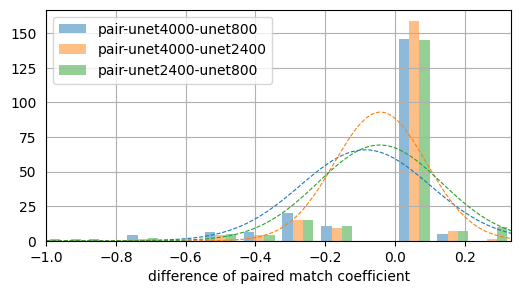

\textit{unet800} & -6.42 & 0.00 \\
\textit{unet800} & -3.46 & 0.00 \\
\textit{unet2400} & -4.44 & 0.00 \\


In [86]:
df_pair=df_all_merged.copy()
df_pair['pair-unet4000-unet800']=df_pair.unet800-df_pair.unet4000
df_pair['pair-unet4000-unet2400']=df_pair.unet2400-df_pair.unet4000
df_pair['pair-unet2400-unet800']=df_pair.unet800-df_pair.unet2400

columns = [ 'pair-unet4000-unet800',  'pair-unet4000-unet2400', 'pair-unet2400-unet800',  ]
histo(df_pair, columns, factor=4, with_stylized=True, filename='histo_unet_pair_ttest', xlabel_prefix='difference of paired ')
ttest(df_pair, 'unet4000','unet800')
ttest(df_pair, 'unet2400','unet800')
ttest(df_pair, 'unet4000','unet2400')

Index(['source', 'input', 'epoch8', 'epoch3', 'pair-input-epoch8',
       'pair-input-epoch3', 'pair-epoch8-epoch3'],
      dtype='object')
\textit{None} & 0.96 & 0.11 \\
\textit{None} & 0.98 & 0.08 \\


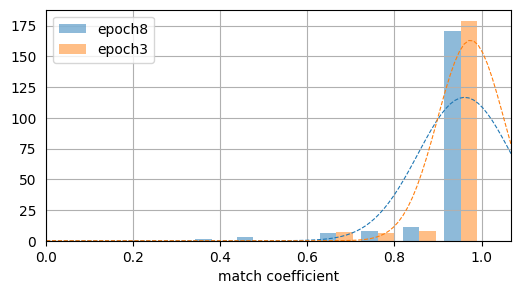

\textit{None} & 0.01 & 0.10 \\


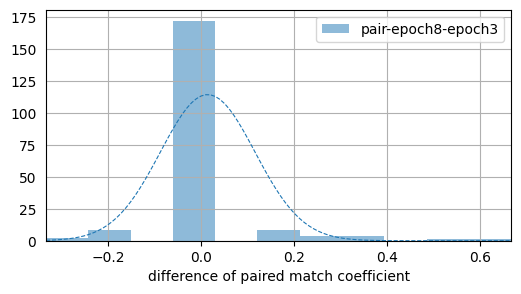

1.96708089638172 0.05056367042139982
\textit{epoch3} & 1.97 & 0.05 \\
-1.96708089638172 0.05056367042139982


In [85]:
df_18_35['pair-epoch8-epoch3']=+df_18_35.epoch3-df_18_35.epoch8

columns = [ 'epoch8',  'epoch3' ]
histo(df_18_35, columns, factor=2.5, with_stylized=True, filename='histo_18_35')
columns = [ 'pair-epoch8-epoch3' ]
histo(df_18_35, columns, factor=3.5, with_stylized=True, filename='histo_18_35_pair', xlabel_prefix='difference of paired ')
ttest(df_18_35,'epoch8', 'epoch3',with_debug=True)
